# DATA COLLECTION, PREPARATION AND VISUALISATION

In [3]:
#Import necessary libraries
import pandas as pd
from pandas import read_csv
from pandas import read_excel
from ydata_profiling import ProfileReport
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import geopandas as gpd
import pycountry_convert as pc
import shapely.geometry
from geopandas import GeoDataFrame as gdp
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import rasterio
%matplotlib inline

In [5]:
#Load biodiversity data
file_path ="C:/Users/Joyce/Downloads/technical_assessment/technical_assessment/biodiversity_data.xlsx"
# Load the Excel file
xls = pd.ExcelFile(file_path)
# Get sheet names
sheet_names = xls.sheet_names
# Read all sheets into a dictionary
df1 = {sheet: pd.read_excel(xls, sheet_name=sheet) for sheet in sheet_names}
# Combine allsheets to a dataFrames into one (assuming they have the same structure)
df1 = pd.concat(df1.values(), ignore_index=True)
df1.head()#Show top 5 values

,Country,Species_Type,Species_Name
0,Algeria,Plant,Citrus limon
1,Algeria,Plant,Eucalyptus globulus
2,Algeria,Plant,Acacia senegal
3,Algeria,Plant,Aloe vera
4,Algeria,Plant,Cedar


In [7]:
#Load Conservation fund data
df2= read_csv ("C:/Users/Joyce/Downloads/technical_assessment/technical_assessment/African_Conservation_Funding.csv")
df2.head()

,Country,Funding (Million USD)
0,Algeria,9.17
1,Angola,4.21
2,Benin,1.38
3,Botswana,4.69
4,Burkina Faso,-15.39


In [9]:
#Check for spelling errors in the biodiversity dataframe
from fuzzywuzzy import process
# Function to detect spelling errors
def detect_spelling_errors(df1, columns_to_check, reference_dict):
    spelling_errors = {}
    for column in columns_to_check:
        if column in df1.columns:
            unique_values = df1[column].unique().tolist()
            correct_values = reference_dict.get(column, [])
            
            for value in unique_values:
                match, score = process.extractOne(value, correct_values)
                if score < 97:
                    spelling_errors[value] = match  
    return spelling_errors

# Function to correct spelling errors
def fix_spelling_errors(df1, columns_to_check, reference_dict):
    spelling_errors = detect_spelling_errors(df1, columns_to_check, reference_dict)
    
    for col in columns_to_check: 
        if col in df1.columns:
            df1[col] = df1[col].replace(spelling_errors)
    
    return df1, spelling_errors

reference_words = {
    "Country": [
        "Algeria", "Cabo Verde", "Republic of Congo","Democratic Republic of the Congo", "Djibouti", "Ethiopia", "Ivory Coast", "Botswana", "Cameroon", "Somalia", 
        "Sao Tome and Principe", "Madagascar", "Morocco", "Rwanda", "South Africa", "Uganda", "Senegal", "Kenya", 
        "Togo", "Nigeria", "Seychelles", "Sudan", "Zambia", "Zimbabwe", "Tanzania", "Comoros", "Equatorial Guinea", 
        "Gabon", "Tunisia", "Angola", "Niger", "Eritrea", "Mauritius", "Chad", "Namibia", "Burkina Faso", "Burundi",
        "Central African Republic", "Guinea-Bissau", "Gambia", "Guinea", "Benin", "Liberia", "Sierra Leone", "Republic of Congo",
        "Malawi", "Lesotho", "Ghana", "Mali", "Mauritania", "Mozambique", "South Sudan", "Libya", "Egypt", "Eswatini"
    ],
}

# Detect spelling errors
spelling_errors = detect_spelling_errors(df1, ["Country"], reference_words)
print("Spelling Errors Detected:", spelling_errors)

# Apply spelling correction
df1, corrections_made = fix_spelling_errors(df1, ["Country"], reference_words)
df1.head()

Spelling Errors Detected: {'Congo': 'Republic of Congo', 'Djiboutg': 'Djibouti', 'Eswatinb': 'Eswatini', 'Ethiopir': 'Ethiopia', 'Gambil': 'Gambia', 'Gambie': 'Gambia', 'Ghanh': 'Ghana', 'Guinee': 'Guinea', 'Guineu': 'Guinea', 'Ivory Coasj': 'Ivory Coast', 'Ivory Coase': 'Ivory Coast', 'Mauritaniw': 'Mauritania', 'Mauritiud': 'Mauritius', 'Nigew': 'Niger', 'Sao Tome and Principr': 'Sao Tome and Principe', 'Senegaz': 'Senegal', 'Sierra Leonx': 'Sierra Leone', 'Sudaa': 'Sudan', 'Tanzanir': 'Tanzania', 'Ugands': 'Uganda', 'Ugandb': 'Uganda'}


,Country,Species_Type,Species_Name
0,Algeria,Plant,Citrus limon
1,Algeria,Plant,Eucalyptus globulus
2,Algeria,Plant,Acacia senegal
3,Algeria,Plant,Aloe vera
4,Algeria,Plant,Cedar


In [11]:
#Check for spelling errors in the biodiversity dataframe
from fuzzywuzzy import process
# Function to detect spelling errors
def detect_spelling_errors(df2, columns_to_check, reference_dict):
    spelling_errors = {}
    for column in columns_to_check:
        if column in df1.columns:
            unique_values = df2[column].unique().tolist()
            correct_values = reference_dict.get(column, [])
            
            for value in unique_values:
                match, score = process.extractOne(value, correct_values)
                if score < 97:
                    spelling_errors[value] = match  
    return spelling_errors

# Function to correct spelling errors
def fix_spelling_errors(df2, columns_to_check, reference_dict):
    spelling_errors = detect_spelling_errors(df2, columns_to_check, reference_dict)
    
    for col in columns_to_check: 
        if col in df2.columns:
            df2[col] = df2[col].replace(spelling_errors)
    
    return df2, spelling_errors

reference_words = {
    "Country": [
        "Algeria", "Cabo Verde", "Republic of Congo","Democratic Republic of the Congo", "Djibouti", "Ethiopia", "Ivory Coast", "Botswana", "Cameroon", "Somalia", 
        "Sao Tome and Principe", "Madagascar", "Morocco", "Rwanda", "South Africa", "Uganda", "Senegal", "Kenya", 
        "Togo", "Nigeria", "Seychelles", "Sudan", "Zambia", "Zimbabwe", "Tanzania", "Comoros", "Equatorial Guinea", 
        "Gabon", "Tunisia", "Angola", "Niger", "Eritrea", "Mauritius", "Chad", "Namibia", "Burkina Faso", "Burundi",
        "Central African Republic", "Guinea-Bissau", "Gambia", "Guinea", "Benin", "Liberia", "Sierra Leone", "Republic of Congo",
        "Malawi", "Lesotho", "Ghana", "Mali", "Mauritania", "Mozambique", "South Sudan", "Libya", "Egypt", "Eswatini"
    ],
}

# Detect spelling errors
spelling_errors2 = detect_spelling_errors(df2, ["Country"], reference_words)
print("Spelling Errors Detected:", spelling_errors2)

# Apply spelling correction
df2, corrections_made = fix_spelling_errors(df2, ["Country"], reference_words)
df2.head()

Spelling Errors Detected: {'Congo': 'Republic of Congo', 'Ethiopix': 'Ethiopia'}


,Country,Funding (Million USD)
0,Algeria,9.17
1,Angola,4.21
2,Benin,1.38
3,Botswana,4.69
4,Burkina Faso,-15.39


In [17]:
#Statistic Report for biodiversity data
profile1 = ProfileReport(df1, title=" Biodiversity_data_statistics_report.html")
profile1.to_notebook_iframe()
profile1.to_file("Biodiversity_data_statistics_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
#Remove duplicate values
df1 = df1.drop_duplicates()
df1

,Country,Species_Type,Species_Name
0,Algeria,Plant,Citrus limon
1,Algeria,Plant,Eucalyptus globulus
2,Algeria,Plant,Acacia senegal
3,Algeria,Plant,Aloe vera
4,Algeria,Plant,Cedar
...,...,...,...
1931,Zimbabwe,Mammal,Gorilla
1932,Zimbabwe,Mammal,Jaguar
1933,Zimbabwe,Mammal,Lion
1934,Zimbabwe,Mammal,North American Beaver


In [21]:
#Statistic Report for conservation fund data
profile2 = ProfileReport(df2, title="Conservation_fund_statistics_Report.html")
profile2.to_notebook_iframe()
profile2.to_file("Conservation_fund_statistics_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [18]:
#Replace negative values with positives
df2["Funding (Million USD)"] = df2["Funding (Million USD)"].apply(lambda x: abs(x))
df2.head()

,Country,Funding (Million USD)
0,Algeria,9.17
1,Angola,4.21
2,Benin,1.38
3,Botswana,4.69
4,Burkina Faso,15.39


In [20]:
#Replace missing value in the conservation fund table
df2.fillna(0, inplace=True)
df2.tail()

,Country,Funding (Million USD)
48,Togo,7.73
49,Tunisia,0.00
50,Uganda,2.86
51,Zambia,13.94
52,Zimbabwe,4.07


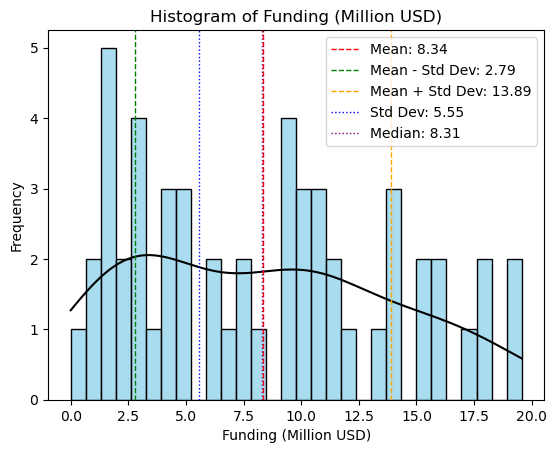

In [22]:
#Plot distribution of funding data
feature = 'Funding (Million USD)'
data = df2[feature]
mean = np.mean(data)
median = np.median(data)
std_dev = np.std(data)

ax = sns.histplot(data, bins=30, kde=True, color='skyblue', edgecolor='black', alpha=0.7)
ax.lines[0].set_color('black')

plt.axvline(mean, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean:.2f}')
plt.axvline(mean - std_dev, color='green', linestyle='dashed', linewidth=1, label=f'Mean - Std Dev: {mean - std_dev:.2f}')
plt.axvline(mean + std_dev, color='orange', linestyle='dashed', linewidth=1, label=f'Mean + Std Dev: {mean + std_dev:.2f}')
plt.axvline(std_dev, color='blue', linestyle='dotted', linewidth=1, label=f'Std Dev: {std_dev:.2f}')
plt.axvline(median, color='purple', linestyle='dotted', linewidth=1, label=f'Median: {median:.2f}')
plt.legend(loc='upper right')

plt.title(f'Histogram of {feature}')
plt.xlabel(feature)
plt.ylabel('Frequency')
plt.show()

In [24]:
#Merge dataframes based on shared column 'Country'
df3 = df1.merge(df2, on='Country')
df3.head()

,Country,Species_Type,Species_Name,Funding (Million USD)
0,Algeria,Plant,Citrus limon,9.17
1,Algeria,Plant,Eucalyptus globulus,9.17
2,Algeria,Plant,Acacia senegal,9.17
3,Algeria,Plant,Aloe vera,9.17
4,Algeria,Plant,Cedar,9.17


In [26]:
# Rename specific country names
df3.loc[df3["Country"] == "Ivory Coast", "Country"] = "Côte d'Ivoire"
df3.head()

,Country,Species_Type,Species_Name,Funding (Million USD)
0,Algeria,Plant,Citrus limon,9.17
1,Algeria,Plant,Eucalyptus globulus,9.17
2,Algeria,Plant,Acacia senegal,9.17
3,Algeria,Plant,Aloe vera,9.17
4,Algeria,Plant,Cedar,9.17


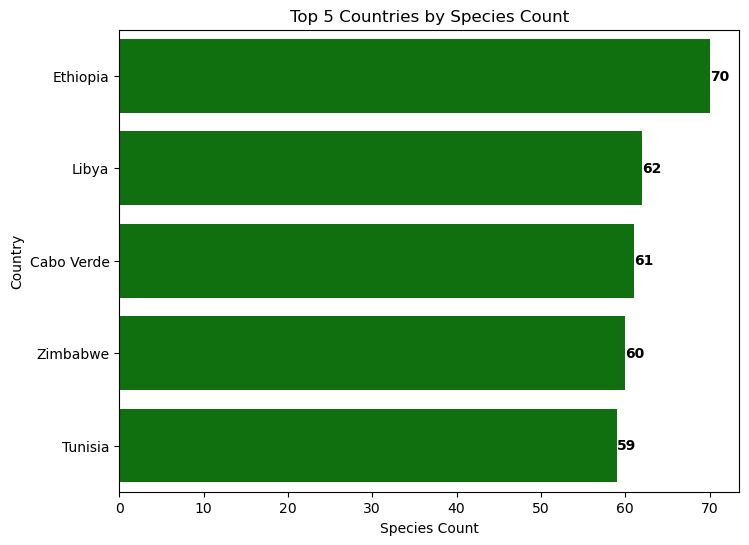

In [28]:
#Display Top 10 countries by species count
species_counts = df3.groupby("Country")["Species_Name"].count().sort_values(ascending=False).head(5)

# Plot Horizontal Bar Graph for Species Count
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=species_counts.values, y=species_counts.index, color="green")

# Add value labels at the end of bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}",  # Display integer species count
                (p.get_width(), p.get_y() + p.get_height() / 2),  # Position at the end of bar
                ha='left', va='center', fontsize=10, fontweight='bold', color='black')

# Add Labels
plt.title("Top 5 Countries by Species Count")
plt.xlabel("Species Count")  # Swapped x-label and y-label for correct orientation
plt.ylabel("Country")

plt.show()

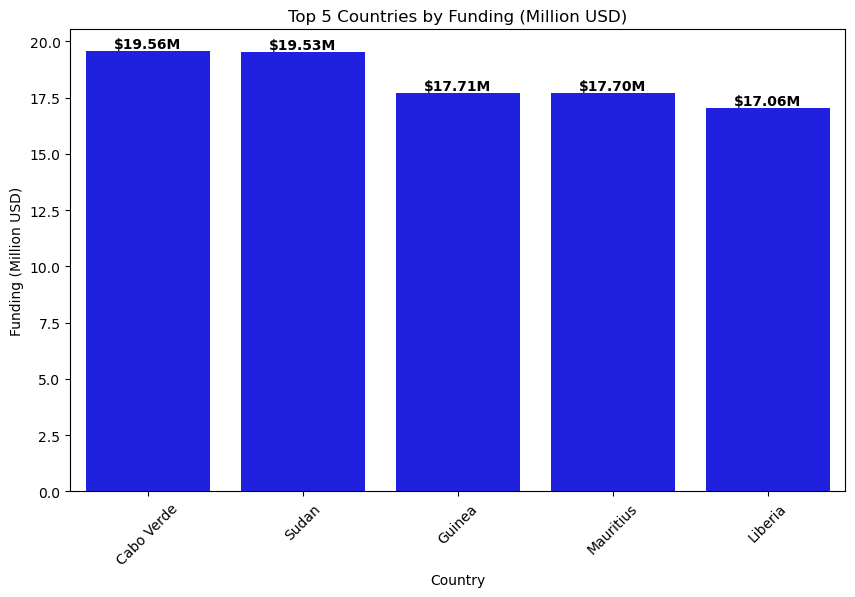

In [106]:
#Display Top 10 countries by funding count
funding_data =df3.groupby("Country").first().reset_index().sort_values(by="Funding (Million USD)", ascending=False).head(5)
# Plot 
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=funding_data, x="Country", y="Funding (Million USD)", color="blue")

# Step 3: Add labels
for p in ax.patches:
    ax.annotate(f"${p.get_height():.2f}M",  # Format funding with 2 decimal places
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

# Add Labels
plt.title("Top 5 Countries by Funding (Million USD)")
plt.xlabel("Country")
plt.ylabel("Funding (Million USD)")
plt.xticks(rotation=45)

plt.show()

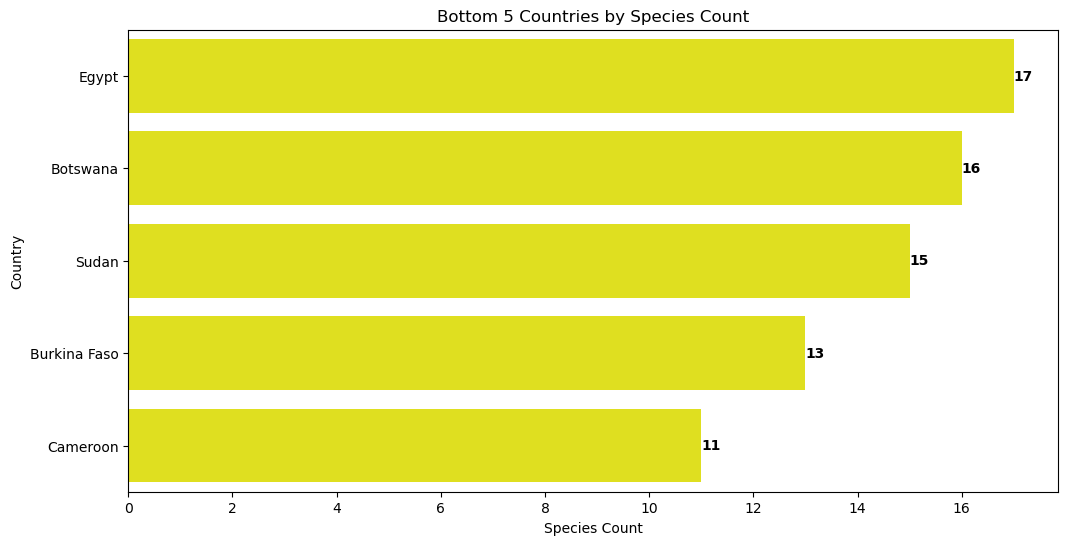

In [31]:
#Display Bottom 10 countries by species count
#Display Top 10 countries by species count
species_counts = df3.groupby("Country")["Species_Name"].count().sort_values(ascending=False).tail(5)

# Plot Horizontal Bar Graph for Species Count
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=species_counts.values, y=species_counts.index, color="yellow")

# Add value labels at the end of bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}",  # Display integer species count
                (p.get_width(), p.get_y() + p.get_height() / 2),  # Position at the end of bar
                ha='left', va='center', fontsize=10, fontweight='bold', color='black')

# Add Labels
plt.title("Bottom 5 Countries by Species Count")
plt.xlabel("Species Count")  # Swapped x-label and y-label for correct orientation
plt.ylabel("Country")

plt.show()

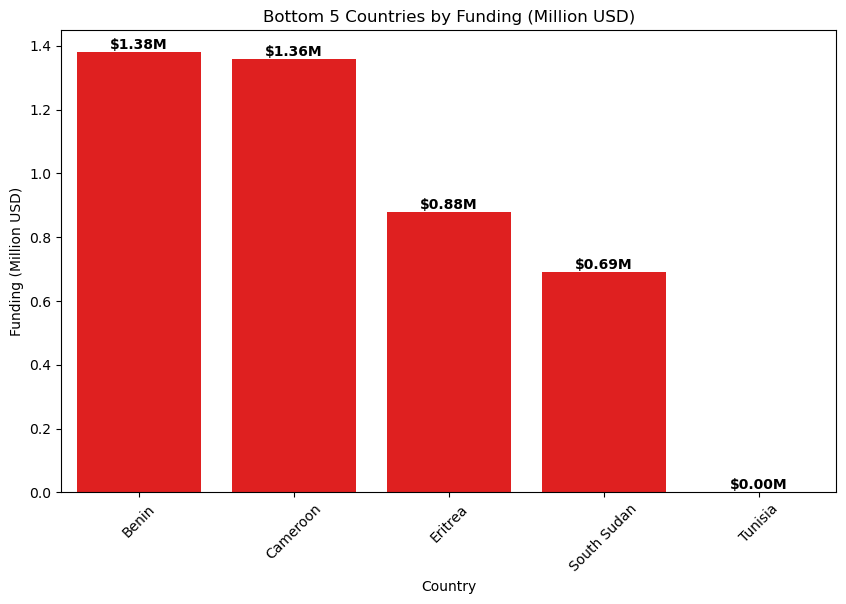

In [104]:
#Sort Bottom 10 countries by funding
funding_data =df3.groupby("Country").last().reset_index().sort_values(by="Funding (Million USD)", ascending=False).tail(5)
# Plot 
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=funding_data, x="Country", y="Funding (Million USD)", color="red")

# Step 3: Add labels
for p in ax.patches:
    ax.annotate(f"${p.get_height():.2f}M",  # Format funding with 2 decimal places
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

# Add Labels
plt.title("Bottom 5 Countries by Funding (Million USD)")
plt.xlabel("Country")
plt.ylabel("Funding (Million USD)")
plt.xticks(rotation=45)

plt.show()

In [33]:
# Show shapefilefile with countries
gdf= gpd.read_file("C:/Users/Joyce/Downloads/technical_assessment/technical_assessment/african_countries_borders/african_countries_borders/african_countries_borders.shp")
gdf.head()

,ADM0_CODE,ADM0_NAME,CONTINENT,ISO3,ISO2,UNI,UNDP,FAOSTAT,GAUL,RIC_ISO3,...,IGAD,IOC,SADC,CICOS,ICPAC,BDMS,MOI,Shape_Leng,Shape_Area,geometry
0,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,4,0,0,0,14,0,0,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ..."
1,8,Angola,Africa,AGO,AO,24.0,ANG,7.0,8.0,BDMS-AGO,...,0,0,6,0,0,16,0,75.453569,103.761908,"MULTIPOLYGON (((11.796 -16.818, 11.794 -16.817..."
2,29,Benin,Africa,BEN,BJ,204.0,BEN,53.0,29.0,CRA-BEN,...,0,0,0,0,0,0,0,21.828985,9.497695,"MULTIPOLYGON (((1.8644 6.2919, 1.8636 6.2925, ..."
3,35,Botswana,Africa,BWA,BW,72.0,BOT,20.0,35.0,BDMS-BWA,...,0,0,6,0,0,16,0,37.886772,50.674566,"POLYGON ((25.175 -17.778, 25.523 -18.385, 25.7..."
4,42,Burkina Faso,Africa,BFA,BF,854.0,BKF,233.0,42.0,CRA-BFA,...,0,0,0,0,0,0,0,31.656255,22.713065,"POLYGON ((-0.45466 15.085, -0.0082057 14.989, ..."


In [34]:
#Check for duplicates
print("\nDuplicated rows in shapefile:") 
gdf.duplicated().sum()


Duplicated rows in shapefile:


0

In [36]:
#Check for missing values
print("Missing values in shapefile:")
gdf.isnull().sum()

Missing values in shapefile:


ADM0_CODE     0
ADM0_NAME     0
CONTINENT     0
ISO3          5
ISO2          5
UNI           0
UNDP          6
FAOSTAT       0
GAUL          0
RIC_ISO3      5
REC_ISO3      5
AFR           0
CEMAC         0
CILSS         0
CRA           0
ECOWAS        0
IGAD          0
IOC           0
SADC          0
CICOS         0
ICPAC         0
BDMS          0
MOI           0
Shape_Leng    0
Shape_Area    0
geometry      0
dtype: int64

In [38]:
#Replace missing value in the conservation fund table
gdf.fillna(0, inplace=True)

In [39]:
#Shapefile statitics
print("\nShapefile summary:")
gdf.describe()


Shapefile summary:


,ADM0_CODE,UNI,FAOSTAT,GAUL,AFR,CEMAC,CILSS,CRA,ECOWAS,IGAD,IOC,SADC,CICOS,ICPAC,BDMS,MOI,Shape_Leng,Shape_Area
count,59.000000,59.000000,59.000000,59.000000,59.0,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000
mean,3231.525424,419.728814,125.101695,809.406780,1.0,0.101695,0.305085,3.745763,0.762712,0.745763,0.338983,1.525424,1.305085,2.372881,4.067797,1.779661,41.729308,43.343656
std,11812.103240,273.250348,81.880842,5292.118711,0.0,0.304841,0.725264,5.938168,1.317508,1.571220,1.267773,2.635016,3.587595,5.297684,7.026709,4.892175,30.605044,50.404758
min,4.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.062593,0.040894
25%,69.000000,179.000000,49.500000,49.500000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.696450,2.373470
50%,145.000000,434.000000,130.000000,106.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,42.511940,22.713065
75%,220.500000,688.000000,195.500000,193.500000,1.0,0.000000,0.000000,13.000000,1.500000,0.000000,0.000000,3.000000,0.000000,0.000000,8.000000,0.000000,59.363564,69.655494
max,61013.000000,894.000000,277.000000,40765.000000,1.0,1.000000,2.000000,13.000000,3.000000,4.000000,5.000000,6.000000,11.000000,14.000000,16.000000,15.000000,130.963852,212.691763


In [40]:
#Shapefile datatypes
print("\nShapefile column data types:")
gdf.dtypes


Shapefile column data types:


ADM0_CODE        int64
ADM0_NAME       object
CONTINENT       object
ISO3            object
ISO2            object
UNI            float64
UNDP            object
FAOSTAT        float64
GAUL           float64
RIC_ISO3        object
REC_ISO3        object
AFR              int32
CEMAC            int64
CILSS            int64
CRA              int64
ECOWAS           int64
IGAD             int64
IOC              int64
SADC             int64
CICOS            int32
ICPAC            int32
BDMS             int32
MOI              int32
Shape_Leng     float64
Shape_Area     float64
geometry      geometry
dtype: object

In [42]:
#Rename Country name Columns
gdf.rename(columns={"ADM0_NAME":"Country"}, inplace=True)
gdf.head()

,ADM0_CODE,Country,CONTINENT,ISO3,ISO2,UNI,UNDP,FAOSTAT,GAUL,RIC_ISO3,...,IGAD,IOC,SADC,CICOS,ICPAC,BDMS,MOI,Shape_Leng,Shape_Area,geometry
0,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,4,0,0,0,14,0,0,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ..."
1,8,Angola,Africa,AGO,AO,24.0,ANG,7.0,8.0,BDMS-AGO,...,0,0,6,0,0,16,0,75.453569,103.761908,"MULTIPOLYGON (((11.796 -16.818, 11.794 -16.817..."
2,29,Benin,Africa,BEN,BJ,204.0,BEN,53.0,29.0,CRA-BEN,...,0,0,0,0,0,0,0,21.828985,9.497695,"MULTIPOLYGON (((1.8644 6.2919, 1.8636 6.2925, ..."
3,35,Botswana,Africa,BWA,BW,72.0,BOT,20.0,35.0,BDMS-BWA,...,0,0,6,0,0,16,0,37.886772,50.674566,"POLYGON ((25.175 -17.778, 25.523 -18.385, 25.7..."
4,42,Burkina Faso,Africa,BFA,BF,854.0,BKF,233.0,42.0,CRA-BFA,...,0,0,0,0,0,0,0,31.656255,22.713065,"POLYGON ((-0.45466 15.085, -0.0082057 14.989, ..."


In [43]:
#Rename row in geodataframe
gdf.loc[gdf["Country"] == "Cape Verde", "Country"] ="Cabo Verde"
gdf.loc[gdf["Country"] == "Swaziland", "Country"] = "Eswatini"
gdf

,ADM0_CODE,Country,CONTINENT,ISO3,ISO2,UNI,UNDP,FAOSTAT,GAUL,RIC_ISO3,...,IGAD,IOC,SADC,CICOS,ICPAC,BDMS,MOI,Shape_Leng,Shape_Area,geometry
0,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,4,0,0,0,14,0,0,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ..."
1,8,Angola,Africa,AGO,AO,24.0,ANG,7.0,8.0,BDMS-AGO,...,0,0,6,0,0,16,0,75.453569,103.761908,"MULTIPOLYGON (((11.796 -16.818, 11.794 -16.817..."
2,29,Benin,Africa,BEN,BJ,204.0,BEN,53.0,29.0,CRA-BEN,...,0,0,0,0,0,0,0,21.828985,9.497695,"MULTIPOLYGON (((1.8644 6.2919, 1.8636 6.2925, ..."
3,35,Botswana,Africa,BWA,BW,72.0,BOT,20.0,35.0,BDMS-BWA,...,0,0,6,0,0,16,0,37.886772,50.674566,"POLYGON ((25.175 -17.778, 25.523 -18.385, 25.7..."
4,42,Burkina Faso,Africa,BFA,BF,854.0,BKF,233.0,42.0,CRA-BFA,...,0,0,0,0,0,0,0,31.656255,22.713065,"POLYGON ((-0.45466 15.085, -0.0082057 14.989, ..."
5,45,Cameroon,Africa,CMR,CM,120.0,CMR,32.0,45.0,CICOS-CMR,...,0,0,0,11,0,0,0,53.616809,38.024712,"MULTIPOLYGON (((9.2654 3.9523, 9.2609 3.9557, ..."
6,47,Cabo Verde,Africa,CPV,CV,132.0,CVI,35.0,47.0,CRA-CPV,...,0,0,0,0,0,0,0,9.076463,0.342430,"MULTIPOLYGON (((-24.698 14.899, -24.679 14.821..."
7,49,Central African Republic,Africa,CAF,CF,140.0,CAF,37.0,49.0,CICOS-CAF,...,0,0,0,11,0,0,0,49.618901,50.682840,"POLYGON ((22.521 11.011, 22.876 10.935, 23.005..."
8,50,Chad,Africa,TCD,TD,148.0,CHD,39.0,50.0,CRA_CICOS-TCD,...,0,0,0,11,0,0,0,55.888607,106.693390,"POLYGON ((24 16.004, 24 15.715, 23.59 15.767, ..."
9,58,Comoros,Africa,COM,KM,174.0,COI,45.0,58.0,MOI-COM,...,0,5,0,0,0,0,15,4.407948,0.137055,"MULTIPOLYGON (((43.72 -12.405, 43.726 -12.41, ..."


In [44]:
#Merge shapefile with merged dataframe
df5 =gdf.merge(df3, on="Country")
df5.head()

,ADM0_CODE,Country,CONTINENT,ISO3,ISO2,UNI,UNDP,FAOSTAT,GAUL,RIC_ISO3,...,CICOS,ICPAC,BDMS,MOI,Shape_Leng,Shape_Area,geometry,Species_Type,Species_Name,Funding (Million USD)
0,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,0,14,0,0,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ...",Plant,Elaeagnus angustifolia,19.53
1,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,0,14,0,0,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ...",Plant,Sassafras albidum,19.53
2,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,0,14,0,0,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ...",Plant,Vanilla planifolia,19.53
3,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,0,14,0,0,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ...",Plant,Hemerocallis,19.53
4,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,0,14,0,0,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ...",Plant,Salvia officinalis,19.53


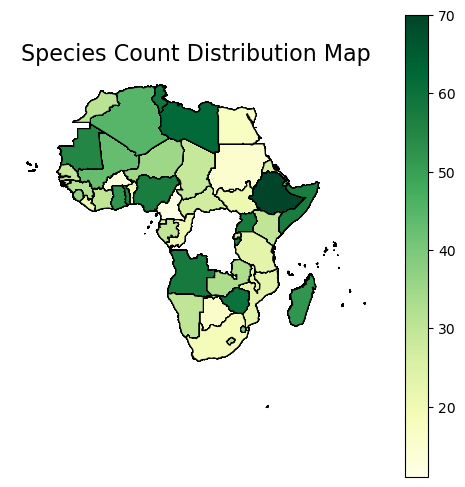

In [45]:
#Plot species distribution
# Set Coordinate Reference System (CRS) for mapping
df5 = df5.to_crs(epsg=4326)

#Count number of species per country
df5["Species_Count"] = df5.groupby("Country")["Species_Type"].transform("count")

# Create a plot
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the shapefile as a choropleth map with an appropriate color scheme
df5.plot(column="Species_Count", cmap="YlGn", linewidth=0.8, edgecolor='black', legend=True, ax=ax)

# Create a custom legend to show species count ranges according to colorscheme assigned
species_counts = df5["Species_Count"].unique()
cmap = plt.get_cmap("YlGn", len(species_counts))
norm = mcolors.Normalize(vmin=df5["Species_Count"].min(), vmax=df5["Species_Count"].max())
legend_patches = [mpatches.Patch(color=cmap(norm(count)), label=f"{count} species") for count in sorted(species_counts)]

# Add a title
ax.set_title("Species Count Distribution Map", fontsize=16)

# Remove axis labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# Display map
plt.show()

In [50]:
#Count Species type
plant_counts = df5[df5["Species_Type"].str.contains("Plant", na=False)].groupby("Country").size()
mammal_counts = df5[df5["Species_Type"].str.contains("Mammal", na=False)].groupby("Country").size()
#Add to dataframe
df5["Plant_Count"] = df5["Country"].map(plant_counts).fillna(0).astype(int)
df5["Mammal_Count"] = df5["Country"].map(mammal_counts).fillna(0).astype(int)
# Display the updated dataframe
df5.head()

,ADM0_CODE,Country,CONTINENT,ISO3,ISO2,UNI,UNDP,FAOSTAT,GAUL,RIC_ISO3,...,MOI,Shape_Leng,Shape_Area,geometry,Species_Type,Species_Name,Funding (Million USD),Species_Count,Plant_Count,Mammal_Count
0,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,0,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ...",Plant,Elaeagnus angustifolia,19.53,15,12,3
1,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,0,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ...",Plant,Sassafras albidum,19.53,15,12,3
2,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,0,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ...",Plant,Vanilla planifolia,19.53,15,12,3
3,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,0,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ...",Plant,Hemerocallis,19.53,15,12,3
4,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,0,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ...",Plant,Salvia officinalis,19.53,15,12,3


In [54]:
# Identify areas with high biodiversity but low funding
biodiversity_threshold = df5["Species_Count"].median()
funding_threshold = df5["Funding (Million USD)"].median()

# Filter for countries with high biodiversity but low funding
high_biodiversity_low_funding = df5[
    (df5["Species_Count"] > biodiversity_threshold) & (df5["Funding (Million USD)"] < funding_threshold)
]

# Select relevant columns and remove duplicates
high_biodiversity_low_funding = high_biodiversity_low_funding[["Country", "Species_Count", "Funding (Million USD)"]].drop_duplicates()

# Sort by S_Count in descending order (highest biodiversity first)
high_biodiversity_low_funding = high_biodiversity_low_funding.sort_values(by="Species_Count", ascending=False)
high_biodiversity_low_funding

,Country,Species_Count,Funding (Million USD)
451,Ethiopia,70,4.01
1709,Libya,62,6.25
1547,Zimbabwe,60,4.07
1854,Tunisia,59,0.00
15,Angola,58,4.21
1433,Uganda,58,2.86
1107,Nigeria,57,2.64
1378,Togo,55,7.73


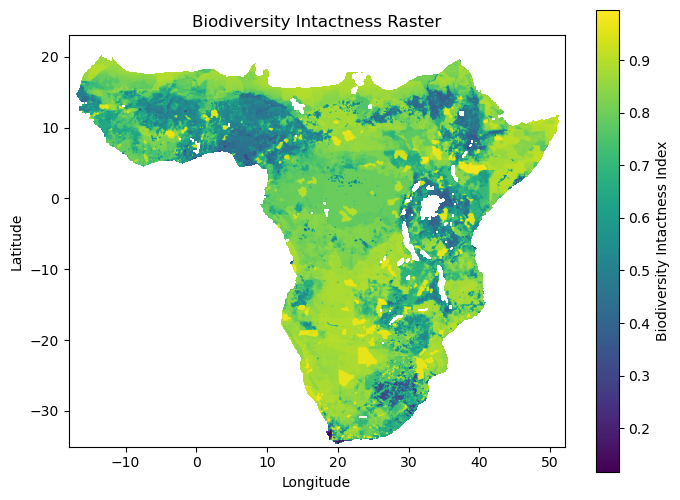

In [55]:
# upload raster file
raster_path = "C:/Users/Joyce/Downloads/technical_assessment/technical_assessment/bii4africa_all.tif"
# Open raster file
with rasterio.open(raster_path) as src:
    raster_data = src.read(1)  # Read first band
    raster_bounds = src.bounds  # Extract raster bounds
# Display the raster file 
plt.figure(figsize=(8, 6))
plt.imshow(raster_data, cmap="viridis", extent=[raster_bounds.left, raster_bounds.right, raster_bounds.bottom, raster_bounds.top])
plt.colorbar(label="Biodiversity Intactness Index")
plt.title("Biodiversity Intactness Raster")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [58]:
# Load raster file
with rasterio.open(raster_path) as src:
    raster_data = src.read(1)  # Read first band
    raster_meta = src.meta
    raster_bounds = src.bounds

    # Filter out NoData values
    valid_data = raster_data[raster_data > 0]
    
    # Compute raster statistics
    stats = {
        "Mean Intactness": np.mean(valid_data),
        "Max Intactness": np.max(valid_data),
        "Min Intactness": np.min(valid_data),
        "Width (px)": src.width,
        "Height (px)": src.height,
        "CRS": str(src.crs),
        "Bounding Box": f"({raster_bounds.left}, {raster_bounds.bottom}, {raster_bounds.right}, {raster_bounds.top})"
    }

raster_df = pd.DataFrame(stats.items(), columns=["Property", "Value"])
raster_df

,Property,Value
0,Mean Intactness,0.756095
1,Max Intactness,0.995363
2,Min Intactness,0.116944
3,Width (px),975
4,Height (px),809
5,CRS,"GEOGCS[""WGS 84"",DATUM[""World Geodetic System 1..."
6,Bounding Box,"(-18.03817, -35.070229999999995, 52.03042, 23...."


In [59]:
#Extract index values from raster file
from rasterstats import zonal_stats #Library for zonal statistics
with rasterio.open(raster_path) as src:
    raster_crs = src.crs  # Get raster CRS
    nodata_value = src.nodata  # Get NoData value (e.g., -9999, 3.4e+38)

# Reproject df5 to match the raster CRS
df5 = df5.to_crs(raster_crs)

# Compute mean BII for each country using zonal statistics
bii_stats = zonal_stats(df5, raster_path, stats=["mean"], nodata=nodata_value)

# Extract mean BII values
df5["Biodiversity_Intactness_Index"] = [
    0 if stat["mean"] is None or stat["mean"] > 1 else stat["mean"]  # Ensure valid BII values (0 to 1 range)
    for stat in bii_stats]
df5.head()

,ADM0_CODE,Country,CONTINENT,ISO3,ISO2,UNI,UNDP,FAOSTAT,GAUL,RIC_ISO3,...,Shape_Leng,Shape_Area,geometry,Species_Type,Species_Name,Funding (Million USD),Species_Count,Plant_Count,Mammal_Count,Biodiversity_Intactness_Index
0,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ...",Plant,Elaeagnus angustifolia,19.53,15,12,3,0.736093
1,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ...",Plant,Sassafras albidum,19.53,15,12,3,0.736093
2,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ...",Plant,Vanilla planifolia,19.53,15,12,3,0.736093
3,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ...",Plant,Hemerocallis,19.53,15,12,3,0.736093
4,6,Sudan,Africa,SDN,SD,729.0,SUD,276.0,6.0,ICPAC-SDN,...,81.911489,155.892802,"MULTIPOLYGON (((38.581 18.029, 38.582 18.027, ...",Plant,Salvia officinalis,19.53,15,12,3,0.736093


In [60]:
#Identify countries with high biodiversity intactness but low funding
# Define thresholds
biodiversity_threshold = df5["Biodiversity_Intactness_Index"].median()
funding_threshold = df5["Funding (Million USD)"].median()

# Identify countries with high biodiversity intactness but low funding
high_bi_low_funding = df5[(df5["Biodiversity_Intactness_Index"] > biodiversity_threshold) & (df5["Funding (Million USD)"] < funding_threshold)
].drop_duplicates(subset=["Country"])

# Sort by Biodiversity Intactness (Highest First)
high_bi_low_funding = high_bi_low_funding.sort_values(by="Biodiversity_Intactness_Index", ascending=False)

# Show selected columns
high_bi_low_funding = high_bi_low_funding[["Country", "Funding (Million USD)", "Biodiversity_Intactness_Index"]]
high_bi_low_funding

,Country,Funding (Million USD),Biodiversity_Intactness_Index
93,Botswana,4.69,0.874608
1042,Namibia,1.52,0.871539
15,Angola,4.21,0.839816
221,Chad,2.95,0.818063
425,Eritrea,0.88,0.806772
194,Central African Republic,4.83,0.804783
284,Republic of Congo,6.50,0.801600
379,South Sudan,0.69,0.795385
521,Gabon,6.75,0.775330
1072,Niger,3.37,0.759611


In [61]:
#Filter dataframe to only show country name, species type, species name and funding available
df6 = df5[["Country", "Species_Name", "Species_Type", "Funding (Million USD)","geometry","Species_Count",
          "Plant_Count","Mammal_Count","Biodiversity_Intactness_Index"]].sort_values(by="Country")
df6.head()

,Country,Species_Name,Species_Type,Funding (Million USD),geometry,Species_Count,Plant_Count,Mammal_Count,Biodiversity_Intactness_Index
1607,Algeria,Citrus limon,Plant,9.17,"MULTIPOLYGON (((-1.9118 35.093, -1.9121 35.092...",45,39,6,0.0
1651,Algeria,Polar Bear,Mammal,9.17,"MULTIPOLYGON (((-1.9118 35.093, -1.9121 35.092...",45,39,6,0.0
1650,Algeria,Snow Leopard,Mammal,9.17,"MULTIPOLYGON (((-1.9118 35.093, -1.9121 35.092...",45,39,6,0.0
1649,Algeria,Brown Bear,Mammal,9.17,"MULTIPOLYGON (((-1.9118 35.093, -1.9121 35.092...",45,39,6,0.0
1648,Algeria,Koala,Mammal,9.17,"MULTIPOLYGON (((-1.9118 35.093, -1.9121 35.092...",45,39,6,0.0


In [62]:
#Rename columns
df6 = df6.rename(columns={"Species_Name": "S_Name", "Species_Type": "S_Type","Funding (Million USD)": "Funds_USD","geometry":"geom",
                         "Plant_Count":"P_Count", "Mammal_Count":"M_Count","Species_Count":"S_Count","Biodiversity_Intactness_Index":"BI_Index"})
df6

,Country,S_Name,S_Type,Funds_USD,geom,S_Count,P_Count,M_Count,BI_Index
1607,Algeria,Citrus limon,Plant,9.17,"MULTIPOLYGON (((-1.9118 35.093, -1.9121 35.092...",45,39,6,0.000000
1651,Algeria,Polar Bear,Mammal,9.17,"MULTIPOLYGON (((-1.9118 35.093, -1.9121 35.092...",45,39,6,0.000000
1650,Algeria,Snow Leopard,Mammal,9.17,"MULTIPOLYGON (((-1.9118 35.093, -1.9121 35.092...",45,39,6,0.000000
1649,Algeria,Brown Bear,Mammal,9.17,"MULTIPOLYGON (((-1.9118 35.093, -1.9121 35.092...",45,39,6,0.000000
1648,Algeria,Koala,Mammal,9.17,"MULTIPOLYGON (((-1.9118 35.093, -1.9121 35.092...",45,39,6,0.000000
...,...,...,...,...,...,...,...,...,...
1571,Zimbabwe,Sandalwood,Plant,4.07,"POLYGON ((29.903 -15.621, 30.425 -15.627, 30.4...",60,46,14,0.715501
1572,Zimbabwe,Lavandula angustifolia,Plant,4.07,"POLYGON ((29.903 -15.621, 30.425 -15.627, 30.4...",60,46,14,0.715501
1573,Zimbabwe,Vitis vinifera,Plant,4.07,"POLYGON ((29.903 -15.621, 30.425 -15.627, 30.4...",60,46,14,0.715501
1575,Zimbabwe,Pistacia vera,Plant,4.07,"POLYGON ((29.903 -15.621, 30.425 -15.627, 30.4...",60,46,14,0.715501


In [69]:
# Export to Shapefile
df6.to_file("Africa_Conservation_data.shp")